# DELTA1: leakage-safe machine-learning extension

## Research objective

Test whether a small, explainable classifier can improve a diversified futures time-series momentum strategy. The decision standard is **unseen 2005–2014 performance after estimated costs**, not in-sample fit.

The primary benchmark is the literature-specified 12-month TSMOM CTA. The ML experiment is deliberately constrained to ridge logistic regression and shallow gradient-boosted trees; this dataset does not justify a large neural network.

This is historical research, not investment advice. It does not claim to reproduce any proprietary trading firm's models.

## Research lineage and pre-declared hypotheses

- Moskowitz, Ooi & Pedersen, [*Time Series Momentum*](https://pages.stern.nyu.edu/~lpederse/papers/TimeSeriesMomentum.pdf): benchmark the sign of the past 12-month return across diversified futures.
- Hurst, Ooi & Pedersen, [*A Century of Evidence on Trend-Following Investing*](https://doi.org/10.3905/jpm.2017.44.1.015): motivates a broad, simple trend prior rather than a narrow optimized rule.
- Moreira & Muir, [*Volatility-Managed Portfolios*](https://www.nber.org/papers/w22208): motivates lagged volatility and volatility-regime features.
- Lim, Zohren & Roberts, [*Enhancing Time Series Momentum Strategies Using Deep Neural Networks*](https://arxiv.org/abs/1904.04912): motivates nonlinear forecast combinations, but also highlights why a deep model needs a much larger panel.
- Gu, Kelly & Xiu, [*Empirical Asset Pricing via Machine Learning*](https://www.nber.org/papers/w25398): motivates nonlinear interactions and disciplined out-of-sample evaluation.
- Bailey et al., [*The Probability of Backtest Overfitting*](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=2326253): motivates the tiny candidate set, nested validation, and reporting of weak variants.

Hypothesis: short/medium/long trend, breakout, volatility regime, cross-sectional context, and lagged public macro stress variables may add information beyond the 12-month sign. Null: they do not survive strict walk-forward testing.

In [1]:
from pathlib import Path
import json
import os
import sys

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT))

from data_engineer_features import save_snapshot_outputs
from delta1_cta import BacktestConfig
from ml_strategy import MLConfig, classification_metrics, run_ml_pipeline

DATA_DIR = Path(os.environ.get(
    "DELTA1_DATA_DIR", str(ROOT / "data" / "Delta1")
))
EXTERNAL_MACRO = Path(os.environ.get(
    "DELTA1_EXTERNAL_MACRO", str(ROOT / "data" / "external" / "fred_macro.csv")
))
DATA_ENGINEER_INPUT = Path(os.environ.get(
    "DELTA1_DATA_ENGINEER_INPUT",
    str(ROOT / "data" / "Data Engineer" / "CFTC_CUMULATIVE_FOREX_2024_04_08.csv"),
))
OUTPUT_DIR = ROOT / "outputs"

assert (DATA_DIR / "CATALOGUE_Delta1_Futures.csv").exists(), "Set DELTA1_DATA_DIR."
assert EXTERNAL_MACRO.exists(), "Run: python download_external_data.py"
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## Data inventory and point-in-time decision

The tradable research panel is 22 USD-denominated, additive back-adjusted futures across equity indices, government bonds, G10 FX, and commodities.

The Desktop Data Engineer folder contains a DTCC/CFTC cumulative FX public-dissemination snapshot and its field guide. The snapshot is valuable as an ingestion prototype—trade count, capped USD notional, tenor, clearing, block, prime-brokerage, and venue measures—but it was published in 2024. Since the supplied futures backtest ends in 2014, using those observations as historical predictors would be direct look-ahead. The audit below therefore excludes it from model fitting.

In [2]:
if DATA_ENGINEER_INPUT.exists():
    save_snapshot_outputs(DATA_ENGINEER_INPUT, OUTPUT_DIR)
    snapshot_audit = json.loads((OUTPUT_DIR / "data_engineer_snapshot_audit.json").read_text())
    display(pd.Series(snapshot_audit, name="DTCC snapshot audit").to_frame())
    display(pd.read_csv(OUTPUT_DIR / "data_engineer_fx_snapshot.csv").head(10))
else:
    print("Optional Data Engineer snapshot not found; set DELTA1_DATA_ENGINEER_INPUT.")

,DTCC snapshot audit
rows,30757
columns,118
unique_dissemination_ids,30757
event_timestamp_min,2021-10-19T14:58:42+00:00
event_timestamp_max,2024-04-08T23:39:33+00:00
new_trade_rows,27818
usd_notional_coverage,0.8848
capped_notional_share,0.0013
usable_in_2005_2014_backtest,False
exclusion_reason,The cumulative slice is a 2024 publication sna...


,pair,trade_count,usd_notional,median_tenor_days,block_share,prime_broker_share,cleared_share,platform_count,capped_notional_share
0,EUR USD,733,"200,000,000,020,661,567,488.0000",9.0000,0.0000,0.0000,0.0000,16,0.0218
1,INR USD,4971,"18,812,789,878.0000",35.0000,0.0000,0.0000,0.0066,27,0.0006
2,JPY USD,428,"16,823,086,768.0000",30.0000,0.0000,0.0000,0.0000,20,0.0070
3,KRW USD,4806,"15,083,554,773.0000",35.0000,0.0000,0.0000,0.0035,28,0.0002
4,BRL USD,2918,"13,401,345,737.0000",32.0000,0.0000,0.0000,0.0000,20,0.0000
5,CNY USD,511,"12,015,454,477.0000",36.0000,0.0000,0.0000,0.0000,17,0.0020
6,TWD USD,3240,"11,784,776,850.0000",32.0000,0.0000,0.0000,0.0108,27,0.0000
7,CLP USD,1483,"7,259,214,358.0000",32.0000,0.0000,0.0000,0.0000,19,0.0000
8,COP USD,1375,"6,531,433,547.0000",32.0000,0.0000,0.0000,0.0000,20,0.0000
9,CAD USD,231,"6,398,452,417.0000",22.0000,0.0000,0.0000,0.0000,14,0.0087


## Online macro data

`download_external_data.py` retrieves three public daily FRED series and writes a timestamped, hashed source manifest:

- [VIXCLS](https://fred.stlouisfed.org/series/VIXCLS): market volatility/stress;
- [T10Y2Y](https://fred.stlouisfed.org/series/T10Y2Y): Treasury curve slope;
- [BAA10Y](https://fred.stlouisfed.org/series/BAA10Y): Baa corporate credit spread over the 10-year Treasury.

Every macro value is short-gap forward-filled and shifted by one business day before feature construction. This conservative rule avoids trading on a same-day observation whose publication time may follow the futures close. A production system should use vintage/release timestamps rather than revised historical downloads.

In [3]:
macro_raw = pd.read_csv(EXTERNAL_MACRO, parse_dates=["Date"])
manifest = json.loads((EXTERNAL_MACRO.parent / "source_manifest.json").read_text())
coverage = pd.DataFrame({
    "first": {c: macro_raw.loc[macro_raw[c].notna(), "Date"].min() for c in macro_raw.columns[1:]},
    "last": {c: macro_raw.loc[macro_raw[c].notna(), "Date"].max() for c in macro_raw.columns[1:]},
    "observations": {c: macro_raw[c].notna().sum() for c in macro_raw.columns[1:]},
})
display(coverage)
print("Provider:", manifest["provider"])
print("Retrieved:", manifest["retrieved_at_utc"])
print("Timing policy:", manifest["timing_policy"])

,first,last,observations
VIXCLS,1990-01-02,2026-07-30,9241
T10Y2Y,1976-06-01,2026-07-31,12538
BAA10Y,1986-01-02,2026-07-30,10144


Provider: Federal Reserve Bank of St. Louis (FRED)
Retrieved: 2026-08-01T17:17:07.399900+00:00
Timing policy: Backtest features are forward-filled only over short publication gaps and lagged one business day before model use.


## Model and timing

At each instrument/month observation, the feature vector contains:

- 1/3/6/12-month trends normalized by lagged 120-day volatility;
- 20-day/120-day volatility ratio, 12-month breakout location, 3-month skew, and downside-day share;
- cross-sectional 12-month trend rank and asset-class trend;
- lagged VIX, yield-curve, and Baa credit-spread levels and 1-month changes;
- the instrument's asset class.

The binary target is the sign of the next month's volatility-normalized price change. Each January:

```text
1997 ... fit history | trailing 24m validation | year Y predictions
                      select 1 of 4 models      labels end < Jan 1 Y
```

Candidate set: ridge logistic regression (`C=0.05, 0.20`) and histogram gradient boosting (depth `1, 2`). Selection minimizes validation log loss, then the winner is refit on every label ending before the test year. Monthly probabilities become a bounded signal and are blended 50/50 with the 12-month trend prior. The target activates on the next business day and enters the same volatility sizing and transaction-cost engine as the baseline.

In [4]:
base_config = BacktestConfig(
    data_dir=DATA_DIR,
    output_dir=OUTPUT_DIR,
    oos_start="2005-01-01",
    oos_end="2014-12-31",
    target_vol=0.10,
    half_spread_ticks=0.50,
    commission_per_contract=2.50,
)
ml_config = MLConfig(
    training_start="1997-01-01",
    prediction_start="2003-01-01",
    prediction_end="2014-12-31",
    validation_months=24,
    ml_blend_weight=0.50,
    probability_scale=0.15,
    random_state=17,
)

result = run_ml_pipeline(base_config, ml_config, EXTERNAL_MACRO)
display(result.metrics.style.format({
    "CAGR": "{:.2%}", "Annualized volatility": "{:.2%}",
    "Sharpe (rf=0)": "{:.2f}", "Max drawdown": "{:.2%}",
    "Annual cost drag": "{:.2%}",
}))

,Start,End,Years,CAGR,Annualized volatility,Sharpe (rf=0),Sortino (rf=0),Max drawdown,Calmar,Positive months,Best month,Worst month,Annual cost drag,Average leverage
Walk-forward ML hybrid CTA,2005-01-03,2014-12-31,10.349206,5.36%,10.80%,0.54,0.868964,-18.22%,0.293860,0.550000,0.090862,-0.080787,0.15%,0.880392
Walk-forward ML-only CTA,2005-01-03,2014-12-31,10.349206,1.03%,10.49%,0.15,0.237536,-19.19%,0.053583,0.508333,0.103092,-0.071568,0.18%,1.272178
12-month TSMOM CTA,2005-01-03,2014-12-31,10.349206,6.93%,10.69%,0.68,1.120267,-20.19%,0.343433,0.533333,0.076604,-0.071976,0.14%,0.601473


## Primary out-of-sample result

The experiment fails the alpha hypothesis: the ML-only and 50/50 hybrid forecasts underperform the 12-month benchmark. This is the central research result, not something to conceal. The simple trend rule remains the recommended forecast under Occam's razor.

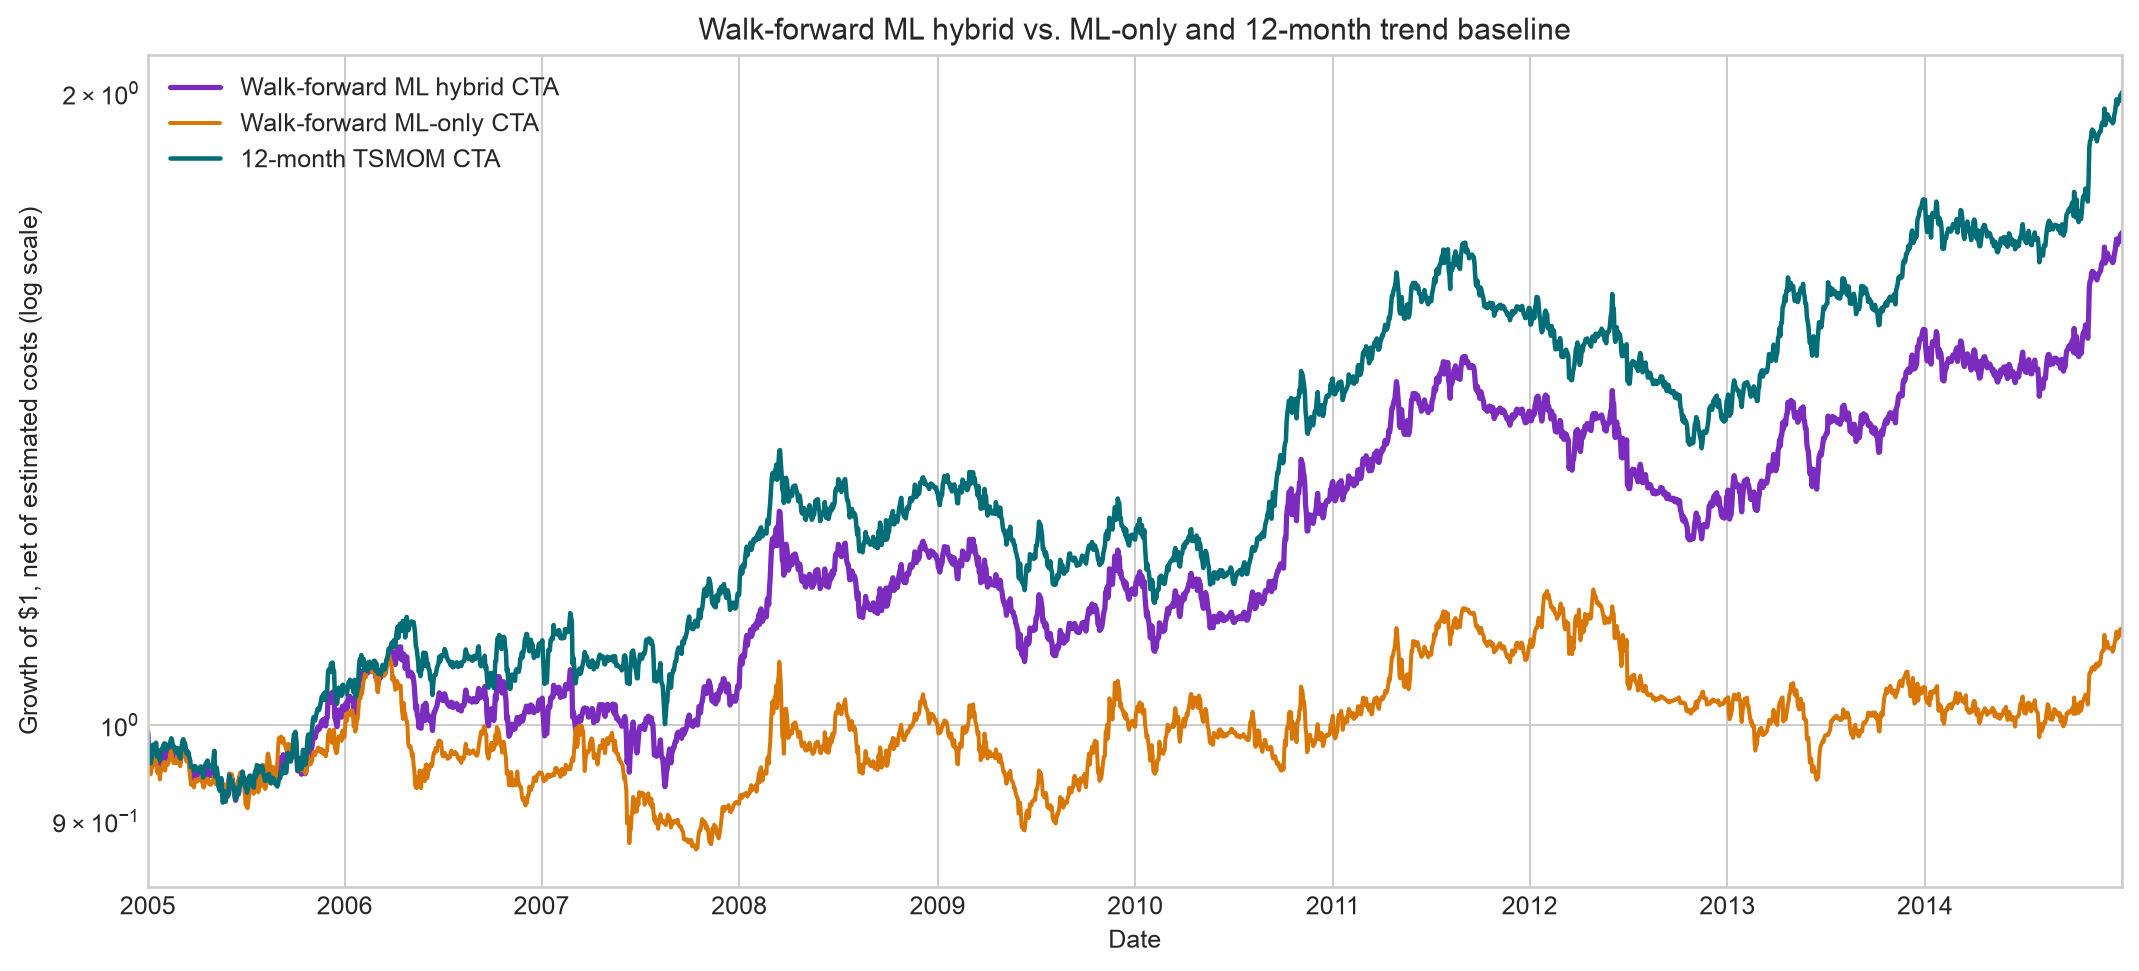

,Walk-forward classifier
Observations,"2,618.0000"
Accuracy,0.5076
Balanced accuracy,0.4984
ROC AUC,0.4908
Log loss,0.7017
Brier score,0.2541
Unconditional up rate,0.5390


In [5]:
display(Image(filename=str(OUTPUT_DIR / "ml_performance.png")))
display(classification_metrics(result.walk_forward.predictions, base_config.oos_start).to_frame())

Classification diagnostics answer a different question from portfolio Sharpe, but here they agree: the classifier has no reliable directional discrimination. The hybrid can still reshape exposure and drawdown because its continuous probabilities interact with risk sizing, but that is not evidence of incremental alpha.

## Nested selections and feature diagnostics

In [6]:
selection = result.walk_forward.model_selection.copy()
selection["timing_pass"] = pd.to_datetime(selection["last_available_label"]) < pd.to_datetime(selection["year"].astype(str) + "-01-01")
display(selection)
assert selection["timing_pass"].all()

model_counts = selection["selected_model"].value_counts().sort_values()
importance = (
    result.walk_forward.feature_importance.groupby("feature")["importance"]
    .mean().sort_values()
)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
model_counts.plot.barh(ax=axes[0], color="#006D77", title="Annual model selections")
importance.tail(12).plot.barh(ax=axes[1], color="#7B2CBF", title="Mean validation permutation importance")
axes[0].set_xlabel("Years selected")
axes[1].set_xlabel("Increase in validation neg-log-loss score")
plt.tight_layout()
plt.show()

,year,selected_model,train_rows,train_start,last_available_label,validation_start,validation_rows,validation_log_loss,validation_auc,timing_pass
0,2003,Shallow GBDT depth=1,1422,1997-01-31,2002-12-31,2000-12-29,512,0.6927,0.5576,True
1,2004,Shallow GBDT depth=2,1686,1997-01-31,2003-12-31,2001-12-31,524,0.6789,0.5428,True
2,2005,Shallow GBDT depth=1,1950,1997-01-31,2004-12-31,2002-12-31,528,0.6844,0.4395,True
3,2006,Ridge logistic C=0.05,2214,1997-01-31,2005-12-30,2003-12-31,528,0.7002,0.5268,True
4,2007,Ridge logistic C=0.05,2478,1997-01-31,2006-12-29,2004-12-31,528,0.7082,0.4713,True
5,2008,Shallow GBDT depth=1,2742,1997-01-31,2007-12-31,2005-12-30,528,0.6940,0.5060,True
6,2009,Shallow GBDT depth=1,3006,1997-01-31,2008-12-31,2006-12-29,528,0.6938,0.4967,True
7,2010,Shallow GBDT depth=2,3270,1997-01-31,2009-12-31,2007-12-31,528,0.6900,0.5543,True
8,2011,Ridge logistic C=0.05,3534,1997-01-31,2010-12-31,2008-12-31,528,0.7062,0.4970,True
9,2012,Shallow GBDT depth=1,3798,1997-01-31,2011-12-30,2009-12-31,528,0.6993,0.4535,True


/var/folders/39/8k2n5j154v72pxxr9yybgbth0000gn/T/ipykernel_35162/3248754920.py:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


Permutation importance is descriptive, not a new selection layer: it is measured on the same trailing validation window used to choose the annual model. Negative or unstable values are evidence against relying on a feature, not permission to search repeatedly until it looks useful.

## Robustness, uncertainty, and subperiods

In [7]:
display(result.robustness.style.format({
    "CAGR": "{:.2%}", "Volatility": "{:.2%}", "Sharpe": "{:.2f}",
    "Max drawdown": "{:.2%}", "Annual cost drag": "{:.2%}",
}))
display(result.bootstrap.style.format({
    "Sharpe 5%": "{:.2f}", "Sharpe median": "{:.2f}",
    "Sharpe 95%": "{:.2f}", "P(Sharpe > 0)": "{:.1%}",
}))
display(pd.read_csv(OUTPUT_DIR / "ml_subperiod_metrics.csv").style.format({
    "CAGR": "{:.2%}", "Volatility": "{:.2%}", "Sharpe": "{:.2f}",
    "Max drawdown": "{:.2%}",
}))

,CAGR,Volatility,Sharpe,Max drawdown,Annual cost drag
Scenario,,,,,
ML blend 25%,6.29%,10.72%,0.62,-19.51%,0.14%
ML blend 50%,5.36%,10.80%,0.54,-18.22%,0.15%
ML blend 75%,4.07%,10.91%,0.42,-17.19%,0.17%
ML blend 100%,1.03%,10.49%,0.15,-19.19%,0.18%
Probability scale 0.10,4.98%,10.91%,0.50,-17.67%,0.15%
Probability scale 0.20,5.59%,10.75%,0.56,-18.63%,0.14%
Probability scale 0.30,5.96%,10.72%,0.59,-19.16%,0.14%
2x trading costs,5.20%,10.80%,0.52,-18.37%,0.30%
3x trading costs,5.04%,10.80%,0.51,-18.51%,0.44%


,Sharpe 5%,Sharpe median,Sharpe 95%,P(Sharpe > 0)
Strategy,,,,
Walk-forward ML hybrid CTA,0.04,0.55,1.02,96.2%
Walk-forward ML-only CTA,-0.29,0.15,0.57,71.5%
12-month TSMOM CTA,0.15,0.67,1.21,98.2%


,Window,Strategy,CAGR,Volatility,Sharpe,Max drawdown
0,2005-2009,Walk-forward ML hybrid CTA,2.81%,10.74%,0.31,-15.21%
1,2005-2009,Walk-forward ML-only CTA,-0.04%,11.03%,0.05,-19.19%
2,2005-2009,12-month TSMOM CTA,4.01%,10.65%,0.42,-14.25%
3,2010-2014,Walk-forward ML hybrid CTA,7.97%,10.87%,0.76,-18.22%
4,2010-2014,Walk-forward ML-only CTA,2.11%,9.91%,0.26,-18.85%
5,2010-2014,12-month TSMOM CTA,9.94%,10.73%,0.94,-20.19%
6,Global Financial Crisis 2008,Walk-forward ML hybrid CTA,14.45%,11.86%,1.20,-11.02%
7,Global Financial Crisis 2008,Walk-forward ML-only CTA,8.74%,12.30%,0.74,-11.56%
8,Global Financial Crisis 2008,12-month TSMOM CTA,11.49%,11.06%,1.04,-10.61%


## Findings and key takeaways

1. **Keep the simple forecast.** The 12-month TSMOM benchmark produces the strongest OOS CAGR and Sharpe in this experiment. The adaptive non-ML strategy in the companion notebook remains the best implementation candidate because its small improvement comes from transparent risk/execution rules.
2. **Do not promote the ML overlay.** OOS ROC AUC is below 0.50 and ML-only portfolio performance is weak. A 25% blend is less damaging than 50%, but choosing it after seeing the test set would be data mining.
3. **Use the failed model as evidence.** Nested annual selection, lagged macro data, explicit label cutoffs, costs, subperiods, and block-bootstrap intervals make the negative result credible.
4. **The Data Engineer snapshot is useful—but not in this backtest.** It is production-oriented feature plumbing for post-2024 live research, not permissible training data for 2005–2014.
5. **Next valid experiment:** obtain point-in-time daily DTCC histories and post-2014 individual-contract futures with roll mappings, freeze the model, and conduct a genuinely untouched forward test.

### Limitations

- Historical FRED downloads can contain revisions; vintage data are preferable.
- The 22-instrument monthly panel is small and cross-sectionally dependent.
- Continuous back-adjusted contracts hide rolls and are not directly executable.
- Costs omit impact, liquidity regimes, margin, and collateral return.
- Bootstrap intervals quantify sampling variation, not model-selection uncertainty.
- Daily bars cannot support market-making, order-book, or execution-alpha claims.